# Assignment 1

By the deadline, please submit the provided Jupyter notebook with all/some required tasks completed and clearly solved. Make sure your code is neat, well-commented, and that all outputs are visible (run all cells before saving). Notebooks with missing tasks or unexecuted cells may receive fewer points. After you submit, you won’t be able to make changes, so double-check your work and be sure to start from the provided template

## Submission rules
As already discussed in class, we will stick to the following rules.
- Use the templates and name your files `NAME_SURNAME.ipynb` (If you have more than one name, just concatenate them). We will compare what you present with that file. 
- Code either not written in Python or not using PyTorch receives a grade of 0. Of course, you can use auxiliary packages when needed (`matplotlib`, `numpy`, ...), but for the learning part, you must use PyTorch.
-  If plagiarism is suspected, TAs and I will thoroughly investigate the situation, and we will summon the student for a face-to-face clarification regarding certain answers they provided. In case of plagiarism, a score reduction will be applied to all the people involved, depending on their level of involvement.
-  If extensive usage of AI tools is detected, we will summon the student for a face-to-face clarification regarding certain answers they provided. If the answers are not adequately supported with in-person answers, we will proceed to apply a penalty to the evaluation, ranging from 10% to 100%.

## Polynomial regression with gradient descent

Let $z \in \mathbb{R}$ and consider the polynomial
\begin{equation}
    p(z) = \frac{z^4}{100} - \frac{z^3}{10} + 5z^2 -z + 1  = {\sum_{ k = 0}^4 z^k w_k}
\end{equation}
where ${w} = [w_0, w_1, w_2, w_3, w_4]^T = [1, -1, 5, -0.1, \frac{1}{100}]^T$. This polynomial can also be expressed as the dot product of two vectors, namely
$$p(z) = {x}{w}^T \quad {x} = [1, z, z^2, z^3, z^4]$$

Consider an independent and identically distributed (i.i.d.) dataset $\mathcal{D} = \{(z_i, y_i)\}_{i = 1}^N$, where $y_i = p(z_i) + \varepsilon_i$, and each $\varepsilon_i$ is drawn from a normal distribution with mean zero and standard deviation $\sigma$.

Now, assuming that the vector ${w}$ is unknown, linear regression could estimate it using the dot-product form presented in the previous Equation. To achieve this, we can move to another dataset
$$\mathcal{D}' := \{({x}_i, y_i)\}_{i = 1}^N \qquad {x}^i =  [1, z_i, z_i^2, z_i^3, z_i^4]$$

The task of this assignment is to perform polynomial regression using gradient descent with PyTorch.

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

### Task 1 (0 pts)
Asses the version of `numpy`, to be sure to read the exact documentation

In [39]:
#TODO
print(np.__version__)  # should be 1.13.1
# i ve a newer but i ll roll with it if it doesnt break stuff

1.26.4


### Task 1 (5 pts)
Define a function `plot_polynomial(coeffs, z_range, color='b')`, where `coeffs` is a `np.array` containing $[w_0, w_1, w_2, w_3, w_4]^T$,  `z_range` is the interval $[z_{\text{min}}, z_{\text{max}}]$ of the $z$ variable; `color` represent a color. Use the function to plot the polynomial in the range $[-4, 4]$. Report the plot. In coding this function, you can use `numpy`.

In [40]:
def plot_polynomial(coeffs, z_range, color='b'):
    """ Plots a polynomial with given coefficients over a specified range
    """
    z = np.linspace(z_range[0], z_range[1], 100) #generate the finite z points for which we ll calculate p(z), as plot requires a discrete approximation
    y = sum(c * z**i for i, c in enumerate(coeffs))#compute p(z) as the linear sum of the terms of the poly. note that the use of enumerate allow for any degree
    #it's not clear weather it should be four as in the example or any
    plt.plot(z, y, color=color) #THE PLOT 
    plt.title('Polynomial Plot') #title
    plt.xlabel('z') #label
    plt.ylabel('p(z)') #label
    plt.show() #show figure

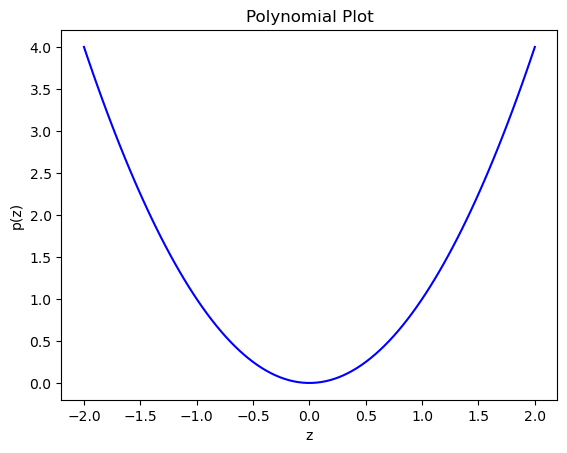

In [41]:
#call for debug
plot_polynomial([0, 0, 1], (-2,2))

### Task 2 (15 pts)
Write a function `create_dataset(coeffs, z_range, sample_size, sigma, seed=42)` that generates the dataset $\mathcal{D'}$.  where `coeffs` is a `np.array` containing $[w_0, w_1, w_2, w_3, w_4]^T$,  `z_range` is the interval $[z_{\text{min}}, z_{\text{max}}]$ of the $z$ variable; `sample_size` is the dimension of the sample; `sigma` is the standard deviation of the normal distrbution from which $\varepsilon_i$ are sampled; `seed` is the seed for the random procedure. Your function must return two `torch.tensor` with the noisy dataset.

In [42]:
def create_dataset(coeffs, z_range, sample_size, sigma, seed=42):
    """ creates a dataset of (z, p(z) + noise) pairs
        coeffs: coefficients of the polynomial
        z_range: as before its the range z lives in (min, max)
        sample_size: number of samples to generate
        sigma: standard deviation of the Gaussian noise
    """
    torch.manual_seed(seed)  # seed is to ensure repeatability when using random stuff. 42 is bc it s the answer to everything :)
    z = (z_range[1] - z_range[0]) * torch.rand(sample_size) + z_range[0]  # there could be a better way to do this but scaling [0,1) to [0, max) and then shift of min
    noise = sigma * torch.randn(sample_size)  # noise [0,sigma)
    y = sum(c * z**i for i, c in enumerate(coeffs)) + noise  # compute poly as before but add the noise
    return z.view(-1, 1), y.view(-1, 1)  # reshape to column vectors (useful later)

### Task 4 (5pts)

Use the code of the previous point to generate data with the following parameters
- Each $z_i$ should be in the interval $[-2, 2]$
- $\sigma = 0.5$
- Use a sample size of 500 for training data and a seed of 0
- Use a sample size of 500 for evaluation data and a seed of 1

In [43]:
coeffs = [1,1,1,1,1] #since no specific coeffs were given, I used repunit of degree 4
#train dataset
dzt, dyt = create_dataset(coeffs, (-2,2), 500, 0.5, seed=0) 
print(dzt[:5])
print(dyt[:5])

#test dataset
dzv, dyv = create_dataset(coeffs, (-2,2), 500, 0.5, seed=1)
print(dzv[:5])
print(dyv[:5])

tensor([[-0.0150],
        [ 1.0729],
        [-1.6461],
        [-1.4719],
        [-0.7703]])
tensor([[ 0.9031],
        [ 5.2982],
        [ 4.4298],
        [ 3.5229],
        [-0.0111]])
tensor([[ 1.0305],
        [-0.8828],
        [-0.3877],
        [ 0.9387],
        [-1.8829]])
tensor([[5.3969],
        [0.6578],
        [0.7912],
        [4.1599],
        [8.9131]])


### Task 5 (10 pts)
Define a function `visualize_data(X, y, coeffs, z_range, title="")` that plots the polynomial $p(z)$ and the generated data, (train and validation), where `X, y` are as returned from the function `create_dataset`, `coeffs` are the coefficient of the polynomial, `z_range` is the interval $[z_{\text{min}}, z_{\text{max}}]$  of the $z$ variable and `title` may be helpful to distinguish between the training and the validation plots. More specifically, provide two plots containing both the true polynomial. In one, add a scatter plot with the training data, and in the other, a scatter plot with the validation data. Use the function to visualize the data.  At this point, you should have noticed that, depending on the circumstances, it is advantageous to store the polynomial coefficients either from the degree 0 term to the degree $n$ term, or vice versa.

In [44]:
def visualize_data(X, y, coeffs, z_range, title=""):
    """ Visualizes the dataset (X,y) and the polynomial defined by coeffs over z_range
    """
    plt.scatter(X.numpy(), y.numpy(), color='r', label='Data points')  # scatter plot
    z = np.linspace(z_range[0], z_range[1], 100)  # everything as before
    p = sum(c * z**i for i, c in enumerate(coeffs)) 
    plt.plot(z, p, color='b', label='Polynomial')  
    plt.xlabel('z')
    plt.ylabel('y')
    plt.show()

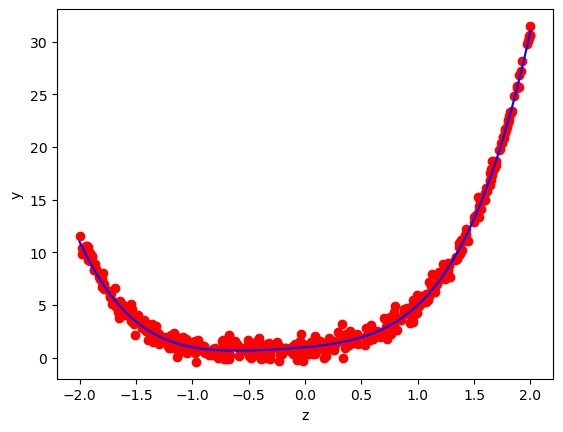

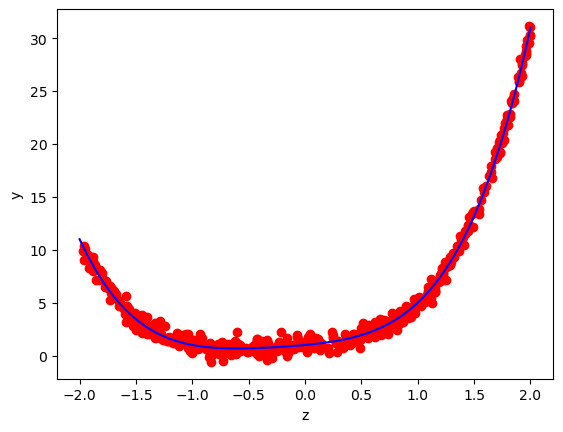

In [45]:
# Application of visualize_data
visualize_data(dzt, dyt, [1,1,1,1,1], (-2,2), title="Training Data with True Polynomial")
visualize_data(dzv, dyv, [1,1,1,1,1], (-2,2), title="Validation Data with True Polynomial")

### Task 6 (30 pts)
Perform polynomial regression on $\mathcal{D}$ using linear regression on $\mathcal{D'}$. You will be asked to motivate
- Which learning rate do you use, and why;
- What happens if the learning rate is too small? What happens if the learning rate is too high, and why?
- If `bias` should be set as `True` or `False` in `torch.nn.Linear` and why. 
- How many steps did you use, and why did you retain that  they were enough

You should use the data you generated at Task 4. 

In [46]:
# TODO
def design_matrix(z, degree):
    powers = [z.squeeze(1)**i for i in range(degree+1)] #compute the powers of z from 0 to degree, 
    #Since the first column corresponds to the power of 0, it is a column of ones. 
    #This column already accounts for the bias term in the model, so bias should be set to False in torch.nn.Linear. 
    # In this case, the bias is treated as part of the weight vector, effectively adding a term +1 * w0 to each polynomial entry.
    return torch.stack(powers, dim=1).float() #stack them to create the design matrix. 
#i ll mention here that the type of variable used to train has an impact, int being faster but less precise and rounding dependant, 
#float64 being more precise but slower. 
#float32 is a good compromise and thats what i'm using

In [47]:
degree = len(coeffs) - 1 
#get degree automatically from coefficients. 
#could be interesting to manually set to an higher number and see if the regression predict a statistically irrelevant coefficient for it (it shouldnt)

X_train = design_matrix(dzt, degree)
y_train = dyt.float()
X_val   = design_matrix(dzv, degree)
y_val   = dyv.float()

model = nn.Linear(X_train.shape[1], 1, bias=False) #the linear reg model from pytorch, arguments are input size, output size and the already mentioned option to use bias out of design matrix
torch.manual_seed(0) #for reproducibility
nn.init.zeros_(model.weight)  # initialize weights to zero

criterion = nn.MSELoss(reduction='mean') #compute mse loss for each element of the batch the averages them.

# chosen optimizer and learning rate.
# an optimizer dictate how the gradient is used to update the weights. 
# i'm using sgd which is straightfoward but require to tune the learning rate hyperparameter and miss some of the nice properties of adam etc
lr = 1e-2 #learning rate, i ve manually selected this as .01 is usually regarded as a good starting point for sgd.
# too high lr can cause overshooting the min, too low can cause too slow convergence
#usually one would do a hyperparameter search to find the best lr (easiest would be to start smal and plot vs loss)
#there's a theorem that states that for convex functions (like mse) sgd will converge for lr<1/L where L is the lipschitz constant of the gradient of the function,
#That for mse is the highest eigenvalue of X^T*X/n (X being the design matrix).
optimizer = optim.SGD(model.parameters(), lr=lr) #Each weight is updated by subtracting a fraction of its gradient, controlled by the learning rate

# training loop (full-batch SGD)
n_steps = 500 #Because i am doing full batch updates, one step means one gradient update using the entire training set.
# Instead of fixed n_steps, one can stop when validation loss stops improving for several checks.
train_losses = []
val_losses = [] #save how losses evolve during time for later plotting
params_history = [] #save how parameters evolve during time for later plotting

for step in range(1, n_steps+1): #Using 1-based indexing for plotting and readability.
    model.train()
    optimizer.zero_grad() #Clears existing gradients of all model parameters.
    preds = model(X_train) #call foward pass under the hood Because i use full batch, this computes the loss and gradients over every training sample in one go.
    loss = criterion(preds, y_train) #call loss
    loss.backward() #Computes the gradient of the loss w.r.t. model parameters. Autograd traverses the computation graph from loss backwards
    #Computing gradients dL/dw for every parameter tensor that has requires_grad=True
    optimizer.step() #The optimizer uses the gradients to update the model parameters according to its update rule (SGD)

    train_losses.append(loss.item())#append float losses

    model.eval()
    with torch.no_grad(): #no grad for this block bc it's just evaluating
        val_loss = criterion(model(X_val), y_val)
        val_losses.append(val_loss.item())
        params_history.append(model.weight.detach().cpu().numpy().ravel().copy()) #save a copy of the current parameters, it's already to cpu etc but in case i decide to run on gpu later
#for long run better to save every n steps instead of every step to save memory
# final outputs
final_params = model.weight.detach().cpu().numpy().ravel()
print("Final parameters (w_0 ... w_d):", final_params)
print("Final train MSE:", train_losses[-1])
print("Final val MSE:", val_losses[-1])

# save arrays to np for later plotting 
train_losses = np.array(train_losses)
val_losses = np.array(val_losses)
params_history = np.array(params_history) 


Final parameters (w_0 ... w_d): [1.0316292  0.9119584  0.87725365 1.0204378  1.0438812 ]
Final train MSE: 0.27767154574394226
Final val MSE: 0.2552960216999054


### Task 7 (10 pts)
Plot the training and validation loss as functions of the iterations and report them in the same plot. If you use both steps and epochs, you can choose either of the two, as long as it is clear from the plot and the plot reports what we expect - namely, that the loss functions decrease.

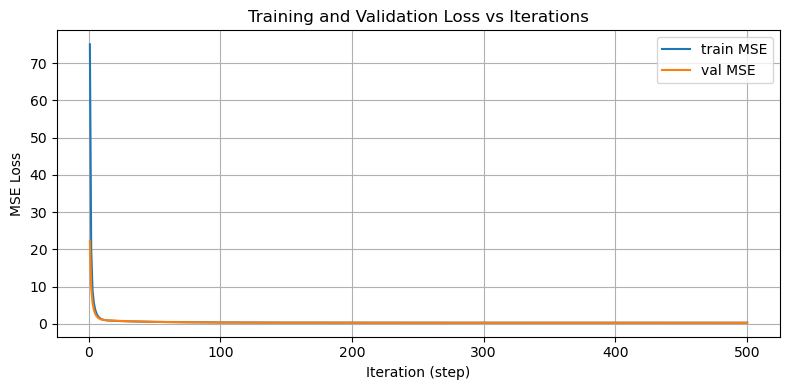

In [48]:
# TODO
n = min(len(train_losses), len(val_losses)) # i do this only in case later i decide to save val losses every n steps instead of every step
train = train_losses[:n] 
val = val_losses[:n]
steps = np.arange(1, n+1) #1-based indexing x axes value

plt.figure(figsize=(8,4))
plt.plot(steps, train, label='train MSE')
plt.plot(steps, val, label='val MSE')
plt.xlabel('Iteration (step)')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss vs Iterations')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

I'd mention that since the task is very easy the performance is great but it's also difficult to see anything from the plot. I could also settle for less steps but there's improving in accuracy whiele using more steps, both in training and val losses.

### Task 8 (10 pts)
Define a function `plot_polynomials(coeffs_list, z_range, color='b')`, where `coeffs_list` is a list containing `np.array`s of type $[w_0, w_1, w_2, w_3, w_4]^T$ of the polynomials you want to plot,  `z_range` is the interval $[z_{\text{min}}, z_{\text{max}}]$ of the $z$ variable; `colors` is a  list of colors, `legend` is a list of labels you want to put. Use the function to plot the polynomial in the range $[-4, 4]$. Report the plot. In coding this function, you can use `numpy`.

In [49]:

def plot_polynomials(coeffs_list, z_range, colors, legend):
    z = np.linspace(z_range[0], z_range[1], 100) #generate the finite z points for which we ll calculate p(z), as plot requires a discrete approximation
    plt.figure(figsize=(8,4))

    curves = [ #create dict
        {"coeffs": coeffs_list[i], "color": colors[i], "label": legend[i]}
        for i in range(len(coeffs_list))
    ]

    for item in curves:
        coeffs = item["coeffs"]
        p = sum(c * z**k for k, c in enumerate(coeffs))
        plt.plot(z, p, color=item["color"], label=item["label"])

    plt.xlabel('z')
    plt.ylabel('p(z)')
    plt.title('Polynomial Evolution During Training')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

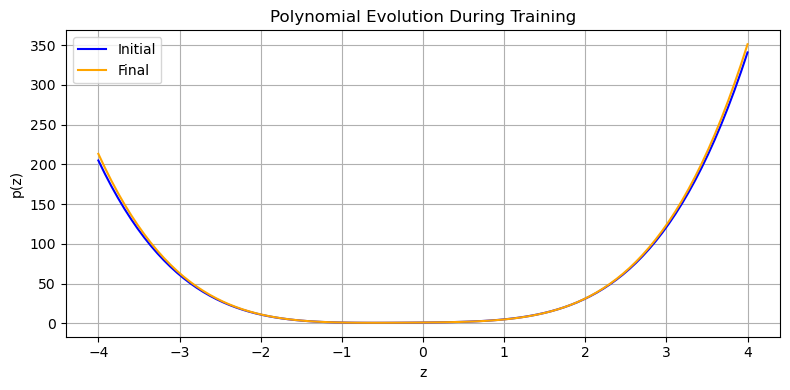

In [50]:
# TODO
coeffs_list = [coeffs, params_history[-1]] 
plot_polynomials(coeffs_list, (-4,4), colors=['blue', 'orange'], legend=['Initial', 'Final'])

### Task 9 (15 points)
Plot the value of the parameters at each iteration, as well as the true value. What we expect is a plot having on the $x$ axis the number of steps/epochs and on the $y$ axis the value of the parameters while they are learned. Then, in the same graph, plot a horizontal line with the true value.

In [51]:
def plot_parameter_trajectory(params_history, coeffs):
    params_history = np.array(params_history)  
    n_steps = params_history.shape[0]
    n_params = params_history.shape[1]
    steps = np.arange(1, n_steps + 1)

    plt.figure(figsize=(10, 5))

    # plot each parameter trajectory
    for j in range(n_params):
        plt.plot(steps, params_history[:, j], label=f'param {j}')

    # plot true parameter values as horizontal lines
    for j in range(n_params):
        plt.axhline(coeffs[j], linestyle='--', label=f'true {j}')

    plt.xlabel('Iteration')
    plt.ylabel('Parameter value')
    plt.title('Parameter Trajectories vs True Values')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


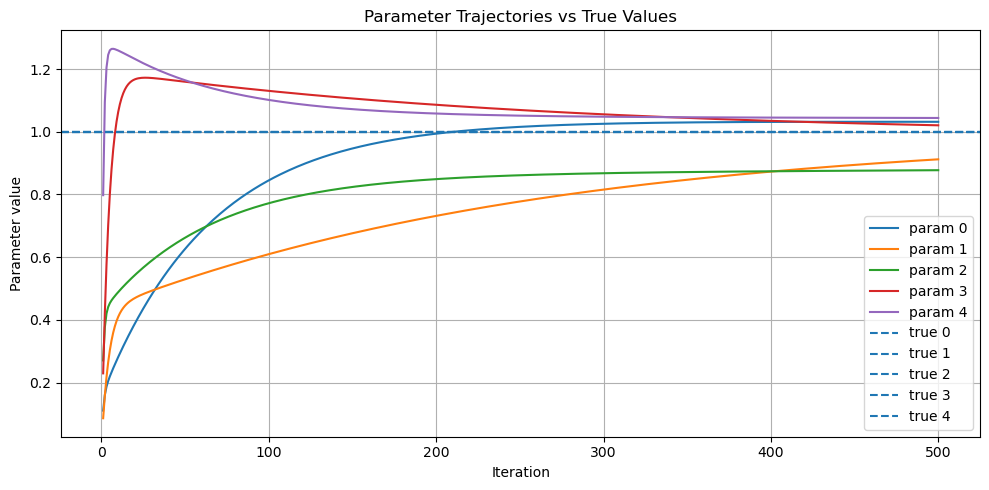

In [52]:
plot_parameter_trajectory(params_history, coeffs)

## Questions

During the presentation, we may ask questions to ensure you have understood the core concepts of the course. Examples include:
- What is the learning rate, and why is it important?
Name a loss function you would use for classification tasks.
-  What are adaptive optimization methods? Can you mention one?
-  What is the difference between steps and epochs?
-  What does the optimizer’s `step()` function do during training?
-  What is a validation set, and why is it used during training?
-  What is overfitting, and how can you reduce it?
-  Why is it necessary to zero out gradients (e.g., `optimizer.zero_grad()`) before the backward pass?

1) it's an hyperparameter that regulates how much the weights are updated using the gradient, cross entropy (usually after softmax (tranform in prob distr) even tho it's hardcoded in the pytorch function) Ep(logq)
2) Instead of using one global learning rate for all parameters, compute a personalized learning rate for each parameter, often changing at every step. Usually, very general statement is that they converge faster but are less stable/likely to find optimal min. ADAM is the most famous, it keeps track of 1 and 2 momentum of past gradients (avg and avg square)
3) Epochs means processing all the data once, step is one update on batch size objects.
4) One step of parameter update
5) it used to do hyperparam opt on unseen data
6) when the model learn too well the data and lose capability of generalizing. More data, simpler model or techniques like dropout etc (there are several)
7) PyTorch walks backward through the computation graph and adds each gradient to any gradient that was already stored in param.grad. If you do not clear them, the next backward pass will add new gradients to the old ones,